# Telco Customer Churn Analysis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

## 1. Data Loading & Exploration

In [4]:
df= pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
print("Shape:", df.shape)

Shape: (7043, 21)


In [6]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.tail(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 2. Data Cleaning

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("hidden missing values in TotalCharges column:", df['TotalCharges'].isnull().sum())

hidden missing values in TotalCharges column: 11


In [10]:
df=df.dropna(subset=['TotalCharges'])
print("Rows Remaining:", df.shape[0])

Rows Remaining: 7032


In [11]:
df.drop_duplicates(inplace=True)
print("Rows Remaining after dropping duplicates:", df.shape[0])

Rows Remaining after dropping duplicates: 7032


## 3. Exploratory Data Analysis (EDA)

In [12]:
churn_rate = df['Churn'].value_counts(normalize=True)*100
print("Churn Rate:", churn_rate)

Churn Rate: Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [13]:
df.groupby('Contract')['Churn'].value_counts(normalize=True) * 100

Contract        Churn
Month-to-month  No       57.290323
                Yes      42.709677
One year        No       88.722826
                Yes      11.277174
Two year        No       97.151335
                Yes       2.848665
Name: proportion, dtype: float64

In [14]:
df.groupby('InternetService')['Churn'].value_counts(normalize=True) * 100

InternetService  Churn
DSL              No       81.001656
                 Yes      18.998344
Fiber optic      No       58.107235
                 Yes      41.892765
No               No       92.565789
                 Yes       7.434211
Name: proportion, dtype: float64

In [15]:
df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True) * 100

SeniorCitizen  Churn
0              No       76.349745
               Yes      23.650255
1              No       58.318739
               Yes      41.681261
Name: proportion, dtype: float64

In [16]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [17]:
df.groupby('Churn')['tenure'].mean()

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

In [18]:
df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True) * 100

PaymentMethod              Churn
Bank transfer (automatic)  No       83.268482
                           Yes      16.731518
Credit card (automatic)    No       84.746877
                           Yes      15.253123
Electronic check           No       54.714588
                           Yes      45.285412
Mailed check               No       80.798005
                           Yes      19.201995
Name: proportion, dtype: float64

In [19]:
df.groupby('PaperlessBilling')['Churn'].value_counts(normalize=True) * 100

PaperlessBilling  Churn
No                No       83.624302
                  Yes      16.375698
Yes               No       66.410749
                  Yes      33.589251
Name: proportion, dtype: float64

## 4. Feature Engineering

In [20]:
df.replace({'No': 0, 'Yes': 1}, inplace=True)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,1,0,No phone service,DSL,0,...,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,0,0,34,1,0,DSL,1,...,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,0,0,2,1,0,DSL,1,...,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,0,0,45,0,No phone service,DSL,1,...,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,0,0,2,1,0,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,1,1,24,1,1,DSL,1,...,1,1,1,1,One year,1,Mailed check,84.80,1990.50,0
7039,2234-XADUH,Female,0,1,1,72,1,1,Fiber optic,0,...,1,0,1,1,One year,1,Credit card (automatic),103.20,7362.90,0
7040,4801-JZAZL,Female,0,1,1,11,0,No phone service,DSL,1,...,0,0,0,0,Month-to-month,1,Electronic check,29.60,346.45,0
7041,8361-LTMKD,Male,1,1,0,4,1,1,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Mailed check,74.40,306.60,1


In [21]:
df = pd.get_dummies(df, columns=['gender', 'InternetService', 
                                  'Contract', 'PaymentMethod'], 
                                  drop_first=True)

In [22]:
df.drop(['customerID'], axis=1, inplace=True)

In [23]:
df.info()
df.head(5)

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   Partner                                7032 non-null   object 
 2   Dependents                             7032 non-null   object 
 3   tenure                                 7032 non-null   int64  
 4   PhoneService                           7032 non-null   object 
 5   MultipleLines                          7032 non-null   object 
 6   OnlineSecurity                         7032 non-null   object 
 7   OnlineBackup                           7032 non-null   object 
 8   DeviceProtection                       7032 non-null   object 
 9   TechSupport                            7032 non-null   object 
 10  StreamingTV                            7032 non-null   object 
 11  StreamingMovies     

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,TotalCharges,Churn,gender_Male,InternetService_DSL,InternetService_Fiber optic,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,No phone service,0,1,0,0,...,29.85,0,False,True,False,False,False,False,True,False
1,0,0,0,34,1,0,1,0,1,0,...,1889.50,0,True,True,False,True,False,False,False,True
2,0,0,0,2,1,0,1,1,0,0,...,108.15,1,True,True,False,False,False,False,False,True
3,0,0,0,45,0,No phone service,1,0,1,1,...,1840.75,0,True,True,False,True,False,False,False,False
4,0,0,0,2,1,0,0,0,0,0,...,151.65,1,False,False,True,False,False,False,True,False


In [24]:
bool_colums = df.select_dtypes('bool').columns
df[bool_colums] = df[bool_colums].astype(int)

In [25]:
df.info()


<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   Partner                                7032 non-null   object 
 2   Dependents                             7032 non-null   object 
 3   tenure                                 7032 non-null   int64  
 4   PhoneService                           7032 non-null   object 
 5   MultipleLines                          7032 non-null   object 
 6   OnlineSecurity                         7032 non-null   object 
 7   OnlineBackup                           7032 non-null   object 
 8   DeviceProtection                       7032 non-null   object 
 9   TechSupport                            7032 non-null   object 
 10  StreamingTV                            7032 non-null   object 
 11  StreamingMovies     

In [26]:
print(df['Churn'].unique())

[0 1]


In [27]:
print(df['Partner'].unique())
print(df['PhoneService'].unique())

[1 0]
[0 1]


In [28]:
df.replace({'No phone service': 0, 'No internet service': 0}, inplace=True)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,TotalCharges,Churn,gender_Male,InternetService_DSL,InternetService_Fiber optic,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,0,0,1,0,0,...,29.85,0,0,1,0,0,0,0,1,0
1,0,0,0,34,1,0,1,0,1,0,...,1889.50,0,1,1,0,1,0,0,0,1
2,0,0,0,2,1,0,1,1,0,0,...,108.15,1,1,1,0,0,0,0,0,1
3,0,0,0,45,0,0,1,0,1,1,...,1840.75,0,1,1,0,1,0,0,0,0
4,0,0,0,2,1,0,0,0,0,0,...,151.65,1,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,24,1,1,1,0,1,1,...,1990.50,0,1,1,0,1,0,0,0,1
7039,0,1,1,72,1,1,0,1,1,0,...,7362.90,0,0,0,1,1,0,1,0,0
7040,0,1,1,11,0,0,1,0,0,0,...,346.45,0,0,1,0,0,0,0,1,0
7041,1,1,0,4,1,1,0,0,0,0,...,306.60,1,1,0,1,0,0,0,0,1


In [29]:

object_cols = df.select_dtypes('object').columns
print(object_cols)

df[object_cols] = df[object_cols].astype(int)


df.info()

Index(['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn'],
      dtype='str')
<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   Partner                                7032 non-null   int64  
 2   Dependents                             7032 non-null   int64  
 3   tenure                                 7032 non-null   int64  
 4   PhoneService                           7032 non-null   int64  
 5   MultipleLines                          7032 non-null   int64  
 6   OnlineSecurity                         7032 non-null   int64  
 7   OnlineBackup                           7032 non-null   int64 

## 5. Visualizations

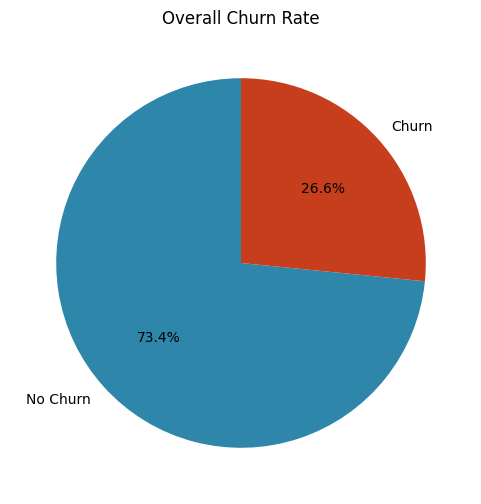

In [30]:
plt.figure(figsize=(6,6))
plt.pie(df['Churn'].value_counts(), labels=['No Churn', 'Churn'], 
        colors=['#2E86AB','#C73E1D'],
        autopct='%1.1f%%', startangle=90)
plt.title("Overall Churn Rate")
plt.show()

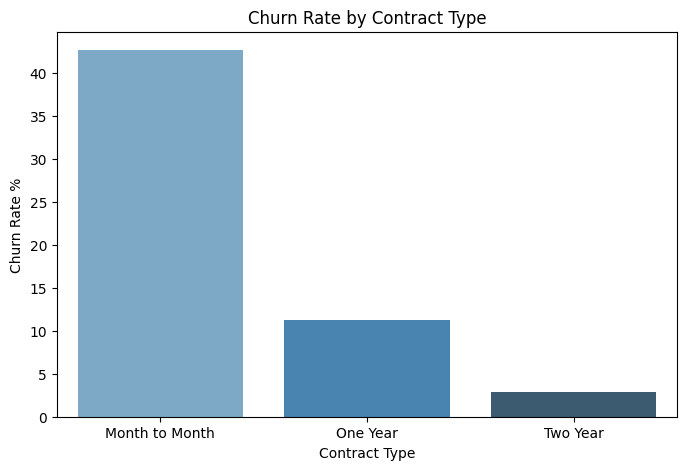

In [31]:
df['contract_type'] = 'Month to Month'
df.loc[df['Contract_One year'] == 1, 'contract_type'] = 'One Year'
df.loc[df['Contract_Two year'] == 1, 'contract_type'] = 'Two Year'

contract_churn = df.groupby('contract_type')['Churn'].mean() * 100

plt.figure(figsize=(8,5))
sns.barplot(x=contract_churn.index, y=contract_churn.values,
            hue=contract_churn.index, palette='Blues_d', legend=False)
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate %")
plt.xticks(rotation=0)
plt.show()

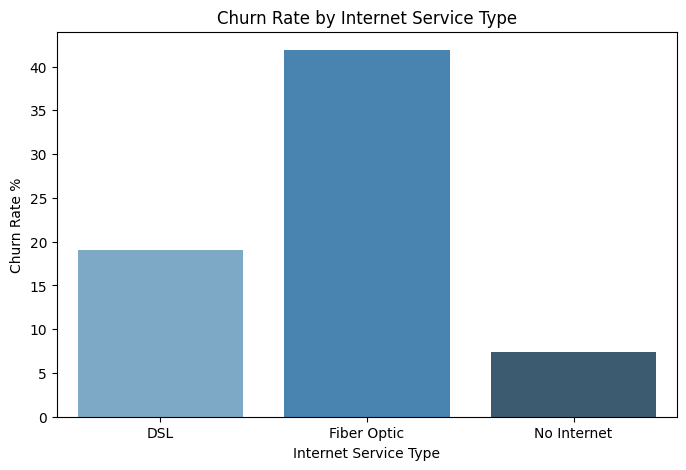

In [32]:
df['Internet_Type'] = 'No Internet'
df.loc[df['InternetService_DSL'] == 1, 'Internet_Type'] = 'DSL'
df.loc[df['InternetService_Fiber optic'] == 1, 'Internet_Type'] = 'Fiber Optic'
InternetService_churn = df.groupby('Internet_Type')['Churn'].mean() * 100

plt.figure(figsize=(8,5))
sns.barplot(x=InternetService_churn.index, y=InternetService_churn.values,
            hue=InternetService_churn.index, palette='Blues_d', legend=False)
plt.title("Churn Rate by Internet Service Type")
plt.xlabel("Internet Service Type")
plt.ylabel("Churn Rate %")
plt.xticks(rotation=0)
plt.show()

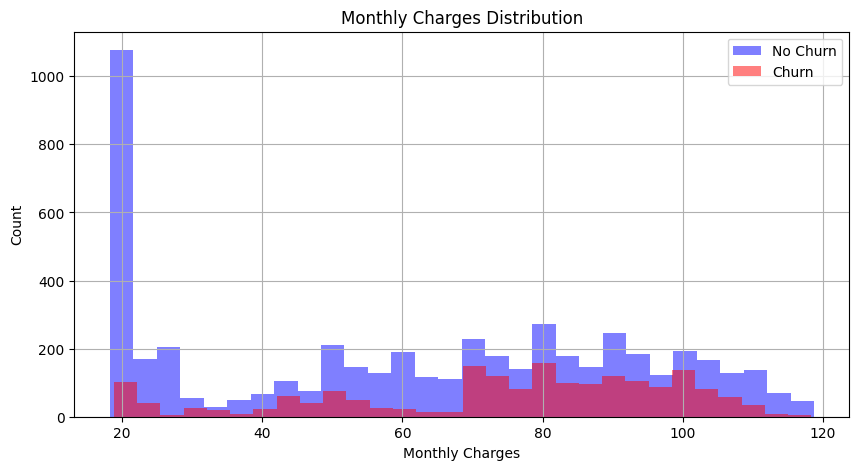

In [33]:
plt.figure(figsize=(10,5))
df[df['Churn']==0]['MonthlyCharges'].hist(bins=30, alpha=0.5, color='blue', label='No Churn')
df[df['Churn']==1]['MonthlyCharges'].hist(bins=30, alpha=0.5, color='red', label='Churn')
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Count")
plt.legend()
plt.show()

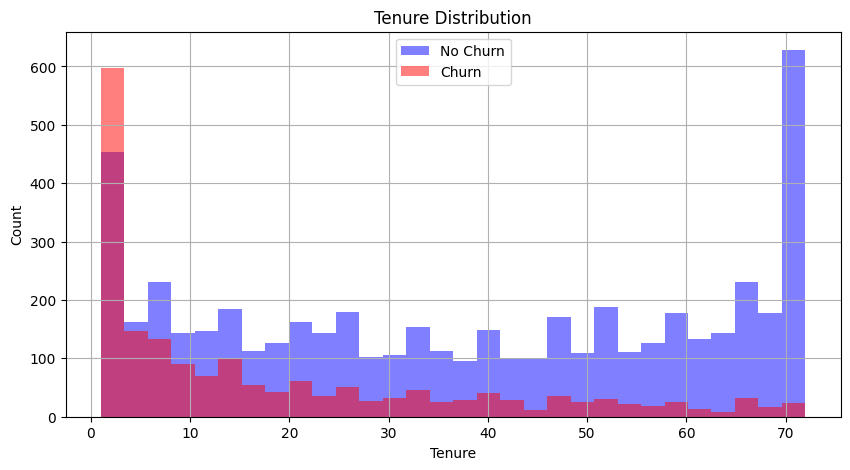

In [34]:
plt.figure(figsize=(10,5))
df[df['Churn']==0]['tenure'].hist(bins=30, alpha=0.5, color='blue', label='No Churn')
df[df['Churn']==1]['tenure'].hist(bins=30, alpha=0.5, color='red', label='Churn')
plt.title("Tenure Distribution")
plt.xlabel("Tenure")
plt.ylabel("Count")
plt.legend()
plt.show()

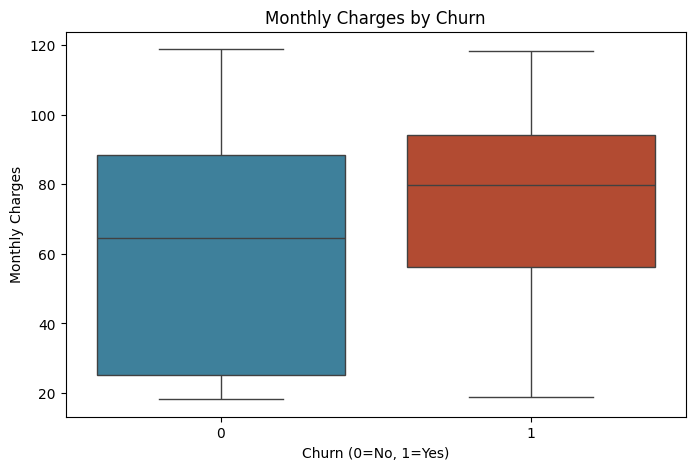

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, 
            hue='Churn', palette=['#2E86AB','#C73E1D'], legend=False)
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn (0=No, 1=Yes)")
plt.ylabel("Monthly Charges")
plt.show()

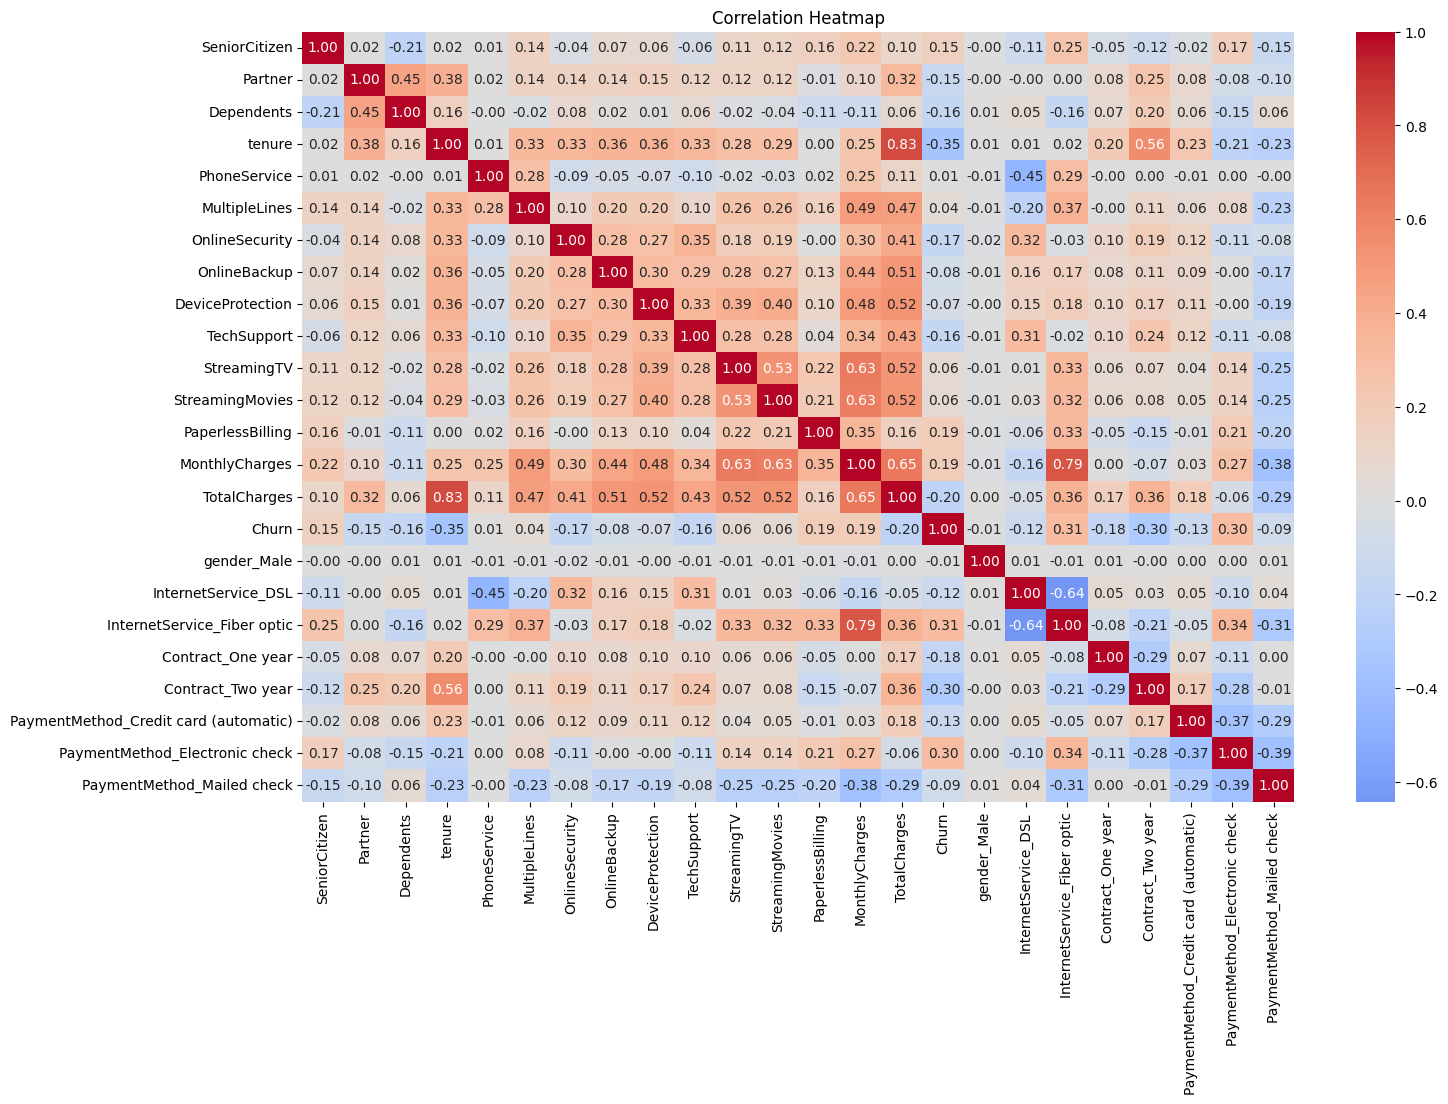

In [36]:
df_corr = df.drop(['contract_type', 'Internet_Type'], axis=1)

plt.figure(figsize=(16,10))
sns.heatmap(df_corr.corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0)
plt.title("Correlation Heatmap")
plt.show()

In [37]:
df.head(5)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,gender_Male,InternetService_DSL,InternetService_Fiber optic,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,contract_type,Internet_Type
0,0,1,0,1,0,0,0,1,0,0,...,0,1,0,0,0,0,1,0,Month to Month,DSL
1,0,0,0,34,1,0,1,0,1,0,...,1,1,0,1,0,0,0,1,One Year,DSL
2,0,0,0,2,1,0,1,1,0,0,...,1,1,0,0,0,0,0,1,Month to Month,DSL
3,0,0,0,45,0,0,1,0,1,1,...,1,1,0,1,0,0,0,0,One Year,DSL
4,0,0,0,2,1,0,0,0,0,0,...,0,0,1,0,0,0,1,0,Month to Month,Fiber Optic


In [38]:
churn_corr = df_corr.corr()['Churn'].sort_values(ascending=False)
print(churn_corr)


Churn                                    1.000000
InternetService_Fiber optic              0.307463
PaymentMethod_Electronic check           0.301455
MonthlyCharges                           0.192858
PaperlessBilling                         0.191454
SeniorCitizen                            0.150541
StreamingTV                              0.063254
StreamingMovies                          0.060860
MultipleLines                            0.040033
PhoneService                             0.011691
gender_Male                             -0.008545
DeviceProtection                        -0.066193
OnlineBackup                            -0.082307
PaymentMethod_Mailed check              -0.090773
InternetService_DSL                     -0.124141
PaymentMethod_Credit card (automatic)   -0.134687
Partner                                 -0.149982
Dependents                              -0.163128
TechSupport                             -0.164716
OnlineSecurity                          -0.171270


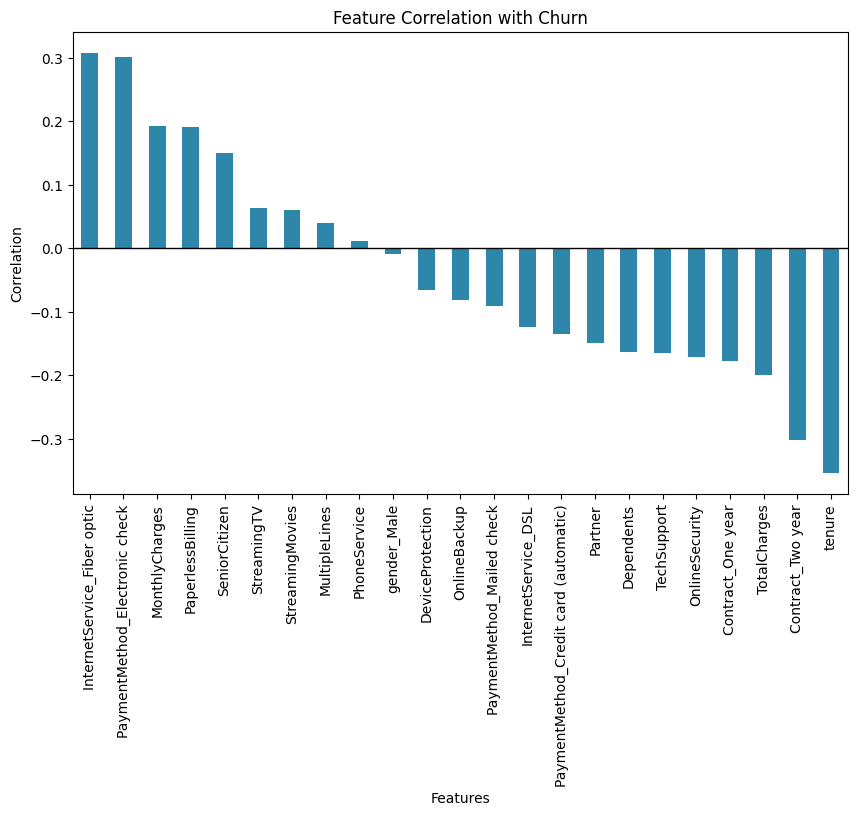

In [39]:
plt.figure(figsize=(10,6))
churn_corr.drop('Churn').plot(kind='bar', color='#2E86AB')
plt.title("Feature Correlation with Churn")
plt.xlabel("Features")
plt.ylabel("Correlation")
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=90)
plt.show()

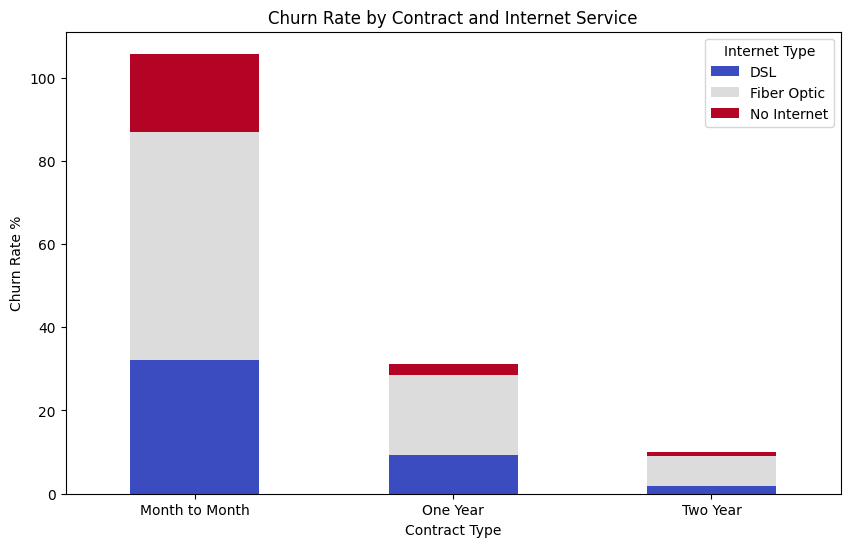

In [40]:
pivot_table = df.groupby(['contract_type', 'Internet_Type'])['Churn'].mean() * 100
pivot_table = pivot_table.unstack()

pivot_table.plot(kind='bar', stacked=True, figsize=(10,6), colormap='coolwarm')
plt.title("Churn Rate by Contract and Internet Service")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate %")
plt.xticks(rotation=0)
plt.legend(title='Internet Type')
plt.show()

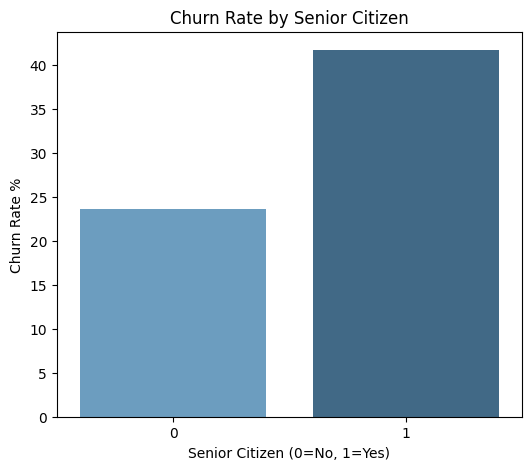

In [41]:
senior_churn = df.groupby('SeniorCitizen')['Churn'].mean() * 100

plt.figure(figsize=(6,5))
sns.barplot(x=senior_churn.index, y=senior_churn.values,
            hue=senior_churn.index, palette='Blues_d', legend=False)
plt.title("Churn Rate by Senior Citizen")
plt.xlabel("Senior Citizen (0=No, 1=Yes)")
plt.ylabel("Churn Rate %")
plt.show()

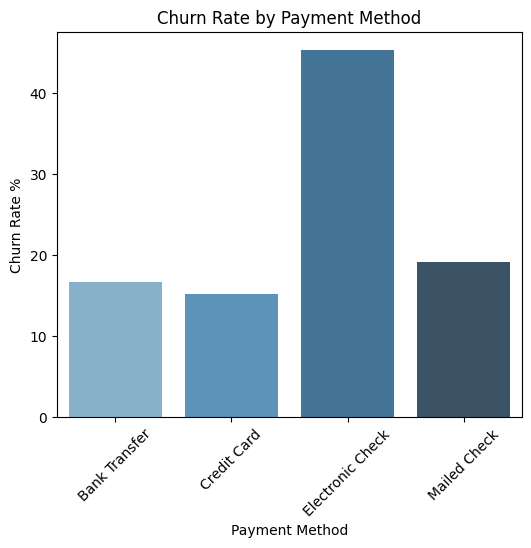

In [42]:
df['Payment_Type'] = 'Bank Transfer'
df.loc[df['PaymentMethod_Credit card (automatic)'] == 1, 'Payment_Type'] = 'Credit Card'
df.loc[df['PaymentMethod_Electronic check'] == 1, 'Payment_Type'] = 'Electronic Check'
df.loc[df['PaymentMethod_Mailed check'] == 1, 'Payment_Type'] = 'Mailed Check'
payment_churn = df.groupby('Payment_Type')['Churn'].mean() * 100

plt.figure(figsize=(6,5))
sns.barplot(x=payment_churn.index, y=payment_churn.values,
            hue=payment_churn.index, palette='Blues_d', legend=False)
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate %")
plt.xticks(rotation=45)
plt.show()



In [43]:
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']

df['Total_Services'] = df[service_cols].sum(axis=1)
print(df['Total_Services'].value_counts())

Total_Services
1    1697
2    1186
3     965
4     921
5     906
6     674
7     395
8     208
0      80
Name: count, dtype: int64


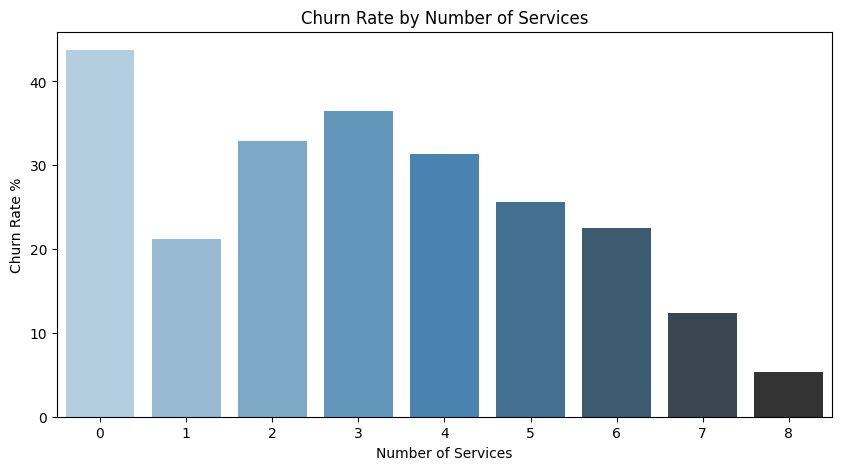

In [44]:
services_churn = df.groupby('Total_Services')['Churn'].mean() * 100

plt.figure(figsize=(10,5))
sns.barplot(x=services_churn.index, y=services_churn.values,
            hue=services_churn.index, palette='Blues_d', legend=False)
plt.title("Churn Rate by Number of Services")
plt.xlabel("Number of Services")
plt.ylabel("Churn Rate %")
plt.show()

In [45]:
#Overall churn rate
print("Churn Rate:")
print(df['Churn'].value_counts(normalize=True) * 100)

#Churn by contract
print("\nChurn by Contract:")
print(df.groupby('contract_type')['Churn'].mean() * 100)

#Average monthly charges
print("\nAvg Monthly Charges:")
print(df.groupby('Churn')['MonthlyCharges'].mean())

#Average tenure
print("\nAvg Tenure:")
print(df.groupby('Churn')['tenure'].mean())

#Churn by internet type
print("\nChurn by Internet:")
print(df.groupby('Internet_Type')['Churn'].mean() * 100)

#Churn by payment method
print("\nChurn by Payment:")
print(df.groupby('Payment_Type')['Churn'].mean() * 100)

#Churn by services
print("\nChurn by Services:")
print(df.groupby('Total_Services')['Churn'].mean() * 100)


Churn Rate:
Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64

Churn by Contract:
contract_type
Month to Month    42.709677
One Year          11.277174
Two Year           2.848665
Name: Churn, dtype: float64

Avg Monthly Charges:
Churn
0    61.307408
1    74.441332
Name: MonthlyCharges, dtype: float64

Avg Tenure:
Churn
0    37.650010
1    17.979133
Name: tenure, dtype: float64

Churn by Internet:
Internet_Type
DSL            18.998344
Fiber Optic    41.892765
No Internet     7.434211
Name: Churn, dtype: float64

Churn by Payment:
Payment_Type
Bank Transfer       16.731518
Credit Card         15.253123
Electronic Check    45.285412
Mailed Check        19.201995
Name: Churn, dtype: float64

Churn by Services:
Total_Services
0    43.750000
1    21.154979
2    32.883642
3    36.476684
4    31.378936
5    25.607064
6    22.551929
7    12.405063
8     5.288462
Name: Churn, dtype: float64


## 📊 Key Business Insights

# 📱 Project 1 — Telco Customer Churn Analysis
**Author:** Mahdi
**Dataset:** IBM Telco Customer Churn
**Tools:** Python, Pandas, Matplotlib, Seaborn

### Dataset Overview
- **Total Customers Analyzed:** 7,032
- **Time Period:** Recent customer data
- **Churn Rate:** 26.6% of customers churned

---

### 1. 📉 Overall Churn Rate
26.6% of customers churned meaning the company 
loses approximately 26 out of every 100 customers.
73.4% of customers remained loyal to the company.
This is a significant churn rate that requires 
immediate business attention.

---

### 2. 📋 Contract Type Impact
Month-to-month customers churn at an alarming 42.7%
compared to only 11.3% for one year contracts and 
just 2.8% for two year contracts.

**Business Recommendation:** Encourage customers to 
switch from month-to-month to longer contracts by 
offering discounts or incentives. This alone could 
reduce churn by up to 40%.

---

### 3. 💰 Monthly Charges Impact
Churned customers pay $74.44 per month on average
compared to $61.31 for customers who stayed.
This $13.13 difference suggests higher pricing 
is a key driver of customer churn.

**Business Recommendation:** Review pricing strategy 
for premium plans and consider offering loyalty 
discounts to high-paying customers.

---

### 4. ⏱️ Tenure Impact
Churned customers stayed only 17.98 months on average
compared to 37.65 months for loyal customers.
New customers are more than twice as likely to churn
as long-term customers.

**Business Recommendation:** Focus retention efforts 
on customers in their first 12 months. Implement 
a new customer onboarding program to improve 
early experience.

---

### 5. 🌐 Internet Service Impact
Fiber Optic customers have the highest churn rate 
at 41.9% despite paying premium prices.
DSL customers churn at only 19.0% and customers 
with no internet service churn at just 7.4%.

**Business Recommendation:** Investigate Fiber Optic 
service quality issues. Higher churn despite higher 
prices suggests customers feel they are not getting 
value for money.

---

### 6. 💳 Payment Method Impact
Electronic Check customers have the highest churn 
rate at 45.3% — nearly 3x higher than Credit Card 
customers at 15.3% and Bank Transfer at 16.7%.
Mailed Check customers churn at 19.2%.

**Business Recommendation:** Encourage customers to 
switch to automatic payment methods (Credit Card or 
Bank Transfer) by offering small discounts. This 
could significantly reduce churn.

---

### 7. 📦 Number of Services Impact
Customers with 0 services churn at 43.8% while 
customers with 8 services churn at only 5.3%.
More services = stronger relationship with company
= lower chance of leaving.

**Business Recommendation:** Create bundle packages 
that encourage customers to subscribe to more 
services. Cross-selling additional services to 
existing customers could dramatically reduce churn.

---

### 🎯 Top 5 Churn Risk Factors
1. Month-to-month contract **(42.7% churn rate)**
2. Electronic check payment **(45.3% churn rate)**
3. Fiber optic internet **(41.9% churn rate)**
4. High monthly charges **($74.44 average)**
5. Low tenure customers **(under 18 months)**

---

### 💡 Overall Business Recommendation
The company should focus on:
1. Converting month-to-month customers to yearly contracts
2. Encouraging automatic payment methods
3. Investigating Fiber Optic service quality
4. Creating retention programs for new customers
5. Bundling services to increase customer stickiness

## 6. Model 1 — Logistic Regression

In [46]:
df_model = df.drop(['contract_type','Internet_Type', 'Payment_Type'], axis=1)
X = df_model.drop('Churn',axis=1)
Y = df_model['Churn']
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=42)
print("X train shape:", X_train.shape)
print("X test shape:", X_test.shape)
print("Y train shape:", Y_train.shape)
print("Y test shape:", Y_test.shape)

X train shape: (5625, 24)
X test shape: (1407, 24)
Y train shape: (5625,)
Y test shape: (1407,)


### ⚠️ Note on Convergence
The model shows a ConvergenceWarning because the dataset 
requires more iterations to fully optimize. This was resolved 
by using StandardScaler (see scaled model below) which 
significantly improves convergence speed and model performance.

In [47]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1500)
model.fit(X_train, Y_train)

c:\Users\T L S\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [48]:
train_accuracy = model.score(X_train, Y_train)
test_accuracy = model.score(X_test, Y_test)
print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.8076444444444445
Test Accuracy: 0.7874911158493249


Accuracy Score: 0.7874911158493249

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



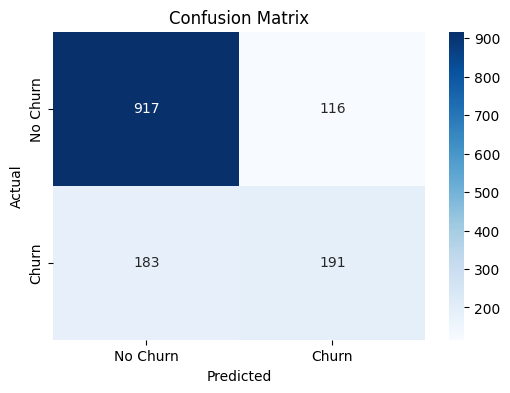

In [49]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
y_pred=model.predict(X_test)
print("Accuracy Score:", accuracy_score(Y_test, y_pred))
print("\nClassification Report:\n", classification_report(Y_test, y_pred))
cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 🤖 Model 1 — Logistic Regression Results

**Model:** Logistic Regression (`max_iter=1500`, solver='lbfgs')
**Train/Test Split:** 80/20 (`random_state=42`)
**Training samples:** 5,625 | **Testing samples:** 1,407

---

### 1. 🎯 Overall Accuracy

- **Training Accuracy:** 80.76%
- **Testing Accuracy:** 78.75%

The close gap (~2%) between train and test accuracy shows the model is **not overfitting** — it generalizes well to unseen customers rather than just memorizing the training data.

---

### 2. 📊 Classification Report

| Class | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| **0 (No Churn)** | 0.83 | 0.89 | 0.86 | 1,033 |
| **1 (Churn)** | 0.62 | 0.51 | 0.56 | 374 |
| **Accuracy** | | | **0.79** | 1,407 |
| **Macro Avg** | 0.73 | 0.70 | 0.71 | 1,407 |
| **Weighted Avg** | 0.78 | 0.79 | 0.78 | 1,407 |

---

### 3. 🔢 Confusion Matrix

| | Predicted: No Churn | Predicted: Churn |
|---|---|---|
| **Actual: No Churn** | 917 ✅ | 116 ❌ |
| **Actual: Churn** | 183 ❌ | 191 ✅ |

- **917** customers correctly predicted to stay
- **191** customers correctly predicted to churn
- **116** false alarms — predicted churn, but customer actually stayed
- **183** missed churners — predicted to stay, but customer actually left (the costliest error for the business)

---

### 4. 🧠 Interpreting Precision & Recall

**Precision (Churn class = 0.62):**
Of all the customers the model predicted would churn, only **62%** actually did. The remaining 38% were false alarms — customers flagged as at-risk who were actually staying.

**Recall (Churn class = 0.51):**
Of all the customers who actually churned, the model only caught **51%** of them. The other 49% (183 customers) were missed entirely — the model predicted they'd stay, but they left.

**Is the model better at predicting churners or non-churners?**
The model performs noticeably better on **non-churners** (F1-score 0.86) than on **churners** (F1-score 0.56). This gap is expected given the class imbalance in the dataset — **73.4% No Churn vs. 26.6% Churn** — which naturally biases the model toward the majority class.

---

### 5. 💡 Business Takeaway

While 79% overall accuracy looks solid at first glance, it's partly inflated by the class imbalance — a model that always predicts "No Churn" would already score ~73% without learning anything. The real weak point is **recall on churners (51%)**: nearly half of at-risk customers go undetected, meaning the business would miss the chance to intervene before they leave.

**Next step (Day 30):** Apply feature scaling (`StandardScaler`) and compare results. Future improvements to explore: `class_weight='balanced'`, adjusting the decision threshold, or testing tree-based models (Random Forest/XGBoost) for potentially better recall on the churn class.

In [50]:
from sklearn.preprocessing  import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)

In [51]:
model_scaled=LogisticRegression(max_iter=1500)
model_scaled.fit(X_train_scaled, Y_train)
train_acc_scaled = model_scaled.score(X_train_scaled, Y_train)
test_acc_scaled = model_scaled.score(X_test_scaled, Y_test)

print("Scaled Training Accuracy:", train_acc_scaled)
print("Scaled Testing Accuracy:", test_acc_scaled)

Scaled Training Accuracy: 0.8092444444444444
Scaled Testing Accuracy: 0.7882018479033405


In [52]:
print("Before scaling — Train:", train_accuracy, "Test:", test_accuracy)
print("After scaling  — Train:", train_acc_scaled, "Test:", test_acc_scaled)


Before scaling — Train: 0.8076444444444445 Test: 0.7874911158493249
After scaling  — Train: 0.8092444444444444 Test: 0.7882018479033405


In [53]:
Y_pred_scaled = model_scaled.predict(X_test_scaled)
print(classification_report(Y_test, Y_pred_scaled))


              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## 7. Model 2 — Random Forest

In [54]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [55]:
rf_train_acc = rf_model.score(X_train, Y_train)
rf_test_acc = rf_model.score(X_test, Y_test)

print("Random Forest Training Accuracy:", rf_train_acc)
print("Random Forest Testing Accuracy:", rf_test_acc)

Random Forest Training Accuracy: 0.9976888888888888
Random Forest Testing Accuracy: 0.783226723525231


In [56]:
print("Logistic Regression — Train:", train_accuracy, "Test:", test_accuracy)
print("Random Forest       — Train:", rf_train_acc, "Test:", rf_test_acc)

Logistic Regression — Train: 0.8076444444444445 Test: 0.7874911158493249
Random Forest       — Train: 0.9976888888888888 Test: 0.783226723525231


In [57]:

importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_10 = importances.sort_values(ascending=False).head(10)
print(top_10)

TotalCharges                      0.188109
MonthlyCharges                    0.166356
tenure                            0.164226
InternetService_Fiber optic       0.046459
Total_Services                    0.044264
PaymentMethod_Electronic check    0.038643
Contract_Two year                 0.032611
gender_Male                       0.027563
PaperlessBilling                  0.026077
Contract_One year                 0.024749
dtype: float64


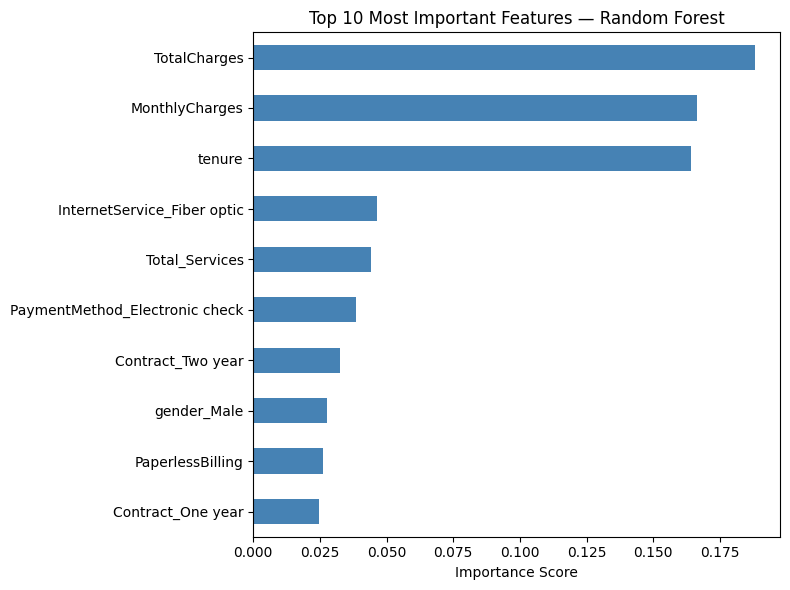

In [58]:
plt.figure(figsize=(8,6))
top_10.sort_values().plot(kind='barh', color='steelblue')
plt.title("Top 10 Most Important Features — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [59]:
for n in [50, 100, 200]:
    rf_temp = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_temp.fit(X_train, Y_train)
    print(f"n_estimators={n} -> Train: {rf_temp.score(X_train, Y_train):.4f}, Test: {rf_temp.score(X_test, Y_test):.4f}")

n_estimators=50 -> Train: 0.9973, Test: 0.7839
n_estimators=100 -> Train: 0.9977, Test: 0.7832
n_estimators=200 -> Train: 0.9977, Test: 0.7882


In [60]:
for depth in [3, 5, 7, 10, None]:
    rf_temp = RandomForestClassifier(max_depth=depth, random_state=42)
    rf_temp.fit(X_train, Y_train)
    print(f"max_depth={depth} -> Train: {rf_temp.score(X_train, Y_train):.4f}, Test: {rf_temp.score(X_test, Y_test):.4f}")

max_depth=3 -> Train: 0.7840, Test: 0.7832
max_depth=5 -> Train: 0.8059, Test: 0.7882
max_depth=7 -> Train: 0.8274, Test: 0.7946
max_depth=10 -> Train: 0.8752, Test: 0.7946
max_depth=None -> Train: 0.9977, Test: 0.7832


In [61]:
final_rf = RandomForestClassifier(max_depth=7, random_state=42)
final_rf.fit(X_train, Y_train)

Y_pred_rf = final_rf.predict(X_test)
print(classification_report(Y_test, Y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1033
           1       0.67      0.44      0.53       374

    accuracy                           0.79      1407
   macro avg       0.75      0.68      0.70      1407
weighted avg       0.78      0.79      0.78      1407



## 8. Model Comparison & Final Selection

In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr_accuracy = accuracy_score(Y_test, Y_pred_scaled)
lr_precision = precision_score(Y_test, Y_pred_scaled)
lr_recall = recall_score(Y_test, Y_pred_scaled)
lr_f1 = f1_score(Y_test, Y_pred_scaled)

rf_accuracy = accuracy_score(Y_test, Y_pred_rf)
rf_precision = precision_score(Y_test, Y_pred_rf)
rf_recall = recall_score(Y_test, Y_pred_rf)
rf_f1 = f1_score(Y_test, Y_pred_rf)

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Logistic Regression': [lr_accuracy, lr_precision, lr_recall, lr_f1],
    'Random Forest': [rf_accuracy, rf_precision, rf_recall, rf_f1]
})

print(comparison)

      Metric  Logistic Regression  Random Forest
0   Accuracy             0.788202       0.794598
1  Precision             0.622581       0.673469
2     Recall             0.516043       0.441176
3   F1 Score             0.564327       0.533118


## 📊 Model Comparison: Logistic Regression vs Random Forest

**Random Forest configuration used:** `max_depth=7`, `random_state=42`
**Logistic Regression configuration used:** `max_iter=1500`, `random_state=42` (train/test split)

---

### Overall Accuracy

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| **Training Accuracy** | 80.76% | 82.74% |
| **Testing Accuracy** | 78.75% | 79.46% |

---

### Classification Report — Class 0 (No Churn)

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Precision | 0.83 | 0.82 |
| Recall | 0.89 | 0.92 |
| F1-Score | 0.86 | 0.87 |

---

### Classification Report — Class 1 (Churn) — the class that matters most

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| **Precision** | 0.62 | **0.67** |
| **Recall** | **0.51** | 0.44 |
| **F1-Score** | **0.56** | 0.53 |

---

### Comparison Table (precise values, from notebook output)

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| **Accuracy** | 0.7882 | **0.7946** |
| **Precision** | 0.6226 | **0.6735** |
| **Recall** | **0.5160** | 0.4412 |
| **F1 Score** | **0.5643** | 0.5331 |

---

### 🏆 Final Comparison Summary

| Metric | Winner |
|---|---|
| Accuracy | Random Forest (79.46% vs 78.75%) |
| Precision (Churn) | Random Forest (0.67 vs 0.62) |
| Recall (Churn) | **Logistic Regression** (0.51 vs 0.44) |
| F1-Score (Churn) | **Logistic Regression** (0.56 vs 0.53) |

---

### 💡 Interpretation

There is no single "best" model here — it's a genuine trade-off:

- **Random Forest** is more confident when it flags a customer as a churn risk (higher precision), but it plays it safe and misses more real churners (lower recall) — it catches only 44% of actual churners.
- **Logistic Regression** catches more real churners overall (51% recall), at the cost of a few more false alarms — but it correctly identifies more at-risk customers who could actually be saved.

**Business conclusion:** In churn prediction, missing an actual churner (a false negative) is typically more costly than a false alarm (a false positive) — the business loses a customer it never got the chance to try to retain. For this reason, **recall on the churn class is the more business-relevant metric**, which favors Logistic Regression despite Random Forest's marginally higher raw accuracy.

## Final Model Selection

I chose **Logistic Regression** as my final model for predicting customer churn.

While Random Forest achieved slightly higher overall accuracy (0.7946 vs 0.7882) and precision (0.6735 vs 0.6226), Logistic Regression achieved better recall (0.5160 vs 0.4412) and F1 score (0.5643 vs 0.5331) on the churn class.

In a churn prediction context, failing to identify an at-risk customer (a false negative) is typically more costly than a false alarm (a false positive) — a missed churner represents lost revenue the business never had a chance to prevent, while a false alarm simply costs a retention offer to a customer who was going to stay anyway.

For this reason, I prioritized recall over marginal accuracy gains and selected Logistic Regression as my final model.

In [63]:
import pickle

with open('churn_model.pkl', 'wb') as f:
    pickle.dump(model_scaled, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Saved model_scaled (Logistic Regression trained on scaled features) to churn_model.pkl")
print("Saved the fitted StandardScaler to scaler.pkl — required to preprocess any new data before prediction")

Saved model_scaled (Logistic Regression trained on scaled features) to churn_model.pkl
Saved the fitted StandardScaler to scaler.pkl — required to preprocess any new data before prediction


In [64]:
with open('churn_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

X_test_scaled_check = loaded_scaler.transform(X_test)

reload_accuracy = loaded_model.score(X_test_scaled_check, Y_test)
print("Reloaded model test accuracy (on properly scaled X_test):", reload_accuracy)
print("Expected accuracy from Day 30:", test_acc_scaled)
print("Match:", round(reload_accuracy, 4) == round(test_acc_scaled, 4))

Reloaded model test accuracy (on properly scaled X_test): 0.7882018479033405
Expected accuracy from Day 30: 0.7882018479033405
Match: True


## Business Report — Telco Customer Churn Analysis

### 1. What is the churn rate?

Out of all customers analyzed, **26.54%** have churned (left the company), while **73.46%** remain active customers. This means roughly 1 in 4 customers is leaving — a significant revenue risk that justifies proactive retention efforts.

### 2. Who is most likely to churn?

Based on the exploratory analysis and model feature importance, customers most likely to churn share these characteristics:

- **Month-to-month contract holders** — churn heavily compared to One-year or Two-year contract customers, who show much stronger retention.
- **Fiber optic internet customers** — churn at a noticeably higher rate than DSL or no-internet customers.
- **Customers with electronic check as their payment method** — show elevated churn compared to other payment types.
- **Newer customers (low tenure)** — customers who haven't been with the company long are at higher risk of leaving.
- **Customers with higher Monthly Charges** — on average, churned customers pay more per month than retained customers.

### 3. What are the top 3 reasons for churn?

1. **Lack of contract commitment** — month-to-month customers can leave anytime with no penalty, and they do so far more often than customers locked into annual contracts.
2. **High monthly cost relative to service** — customers paying more (especially Fiber optic users) appear more price-sensitive and more likely to leave, possibly due to cost concerns or dissatisfaction relative to price.
3. **Early-tenure dissatisfaction** — newer customers haven't yet built loyalty or seen long-term value, making them more likely to leave in their first months.

### 4. What should the business do about it?

- **Incentivize longer contracts**: Offer discounts or perks for switching from month-to-month to one- or two-year contracts, directly targeting the biggest churn driver.
- **Review Fiber optic pricing/service quality**: Investigate why Fiber optic customers churn more — this could be a pricing issue, competition, or service reliability concern worth addressing directly.
- **Improve early-tenure engagement**: Introduce onboarding check-ins, loyalty rewards, or proactive support in customers' first few months, when churn risk is highest.
- **Target electronic check users**: Encourage a switch to automatic payment methods (which correlate with lower churn), possibly through small incentives.
- **Use the prediction model proactively**: Deploy the churn model to flag at-risk customers each month, allowing the retention team to reach out before they cancel, rather than reacting after the fact.

### 5. How accurate is the prediction model?

Two models were built and compared:

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Accuracy | 78.82% | 79.46% |
| Precision (Churn) | 62.26% | 67.35% |
| Recall (Churn) | 51.60% | 44.12% |
| F1 Score (Churn) | 0.5643 | 0.5331 |

**Logistic Regression was selected as the final model**, prioritizing recall (catching more actual churners) over Random Forest's slightly higher raw accuracy — since missing a real churner is more costly to the business than a false alarm. The final model correctly identifies **51.6% of customers who will churn**, giving the business a meaningful head start on retention efforts, though there remains room for improvement (nearly half of churners are still missed, suggesting this should be one input among several in a retention strategy, not a standalone solution).